In [1]:
from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from src.utils import plot_intervals

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pynapple as nap

from replay_trajectory_classification import SortedSpikesDecoder, SortedSpikesClassifier
unit_id = '116b'

# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\multiunit_likelihood.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Decoding

In [2]:
# 2 ms bins
spikes = hd_spikes.restrict(hd_angle.time_support).count(bin_size=2, time_units='ms').astype(np.bool)
spikes = spikes.astype(np.int8)

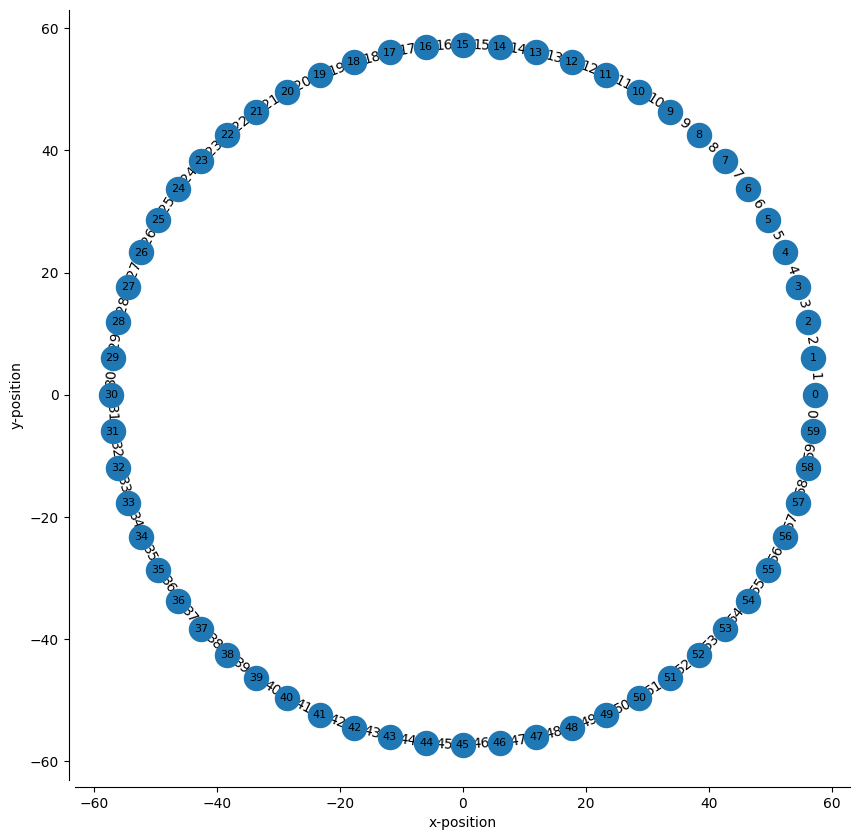

In [10]:
from replay_trajectory_classification import make_track_graph, plot_track_graph

angle = np.linspace(0, 2*np.pi, num=60, endpoint=False)
radius = 180/np.pi

node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

node_ids = np.arange(node_positions.shape[0])
edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

track_graph = make_track_graph(node_positions, edges)

edge_spacing = 0
n_nodes = len(track_graph.nodes)
edge_order = np.stack((np.roll(np.arange(n_nodes-1, -1, -1), 1),
                       np.arange(n_nodes-1, -1, -1)), axis=1)

fig, ax = plt.subplots(figsize=(10, 10))
plot_track_graph(track_graph, ax=ax, draw_edge_labels=True)
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax.set_xlabel("x-position")
ax.set_ylabel("y-position")
sns.despine(offset=5)

In [15]:
# 1 ms bin alignment
# angle = hd_angle.values
# t = hd_angle.index.values
# angle = (angle[1::] + angle[:-1:]) / 2
# t = (t[1::] + t[:-1:]) / 2

# 2 ms bin alignment
# angle = nap.Tsd(t=t, d=angle)
angle = hd_angle.bin_average(bin_size=2, time_units='ms')
angle

Time (s)
----------  -----
16663.101    38.5
16663.103    38
16663.105    37
16663.107    37
16663.109    36
16663.111    35.5
16663.113    35
...
18772.627   299
18772.629   299
18772.631   299
18772.633   299
18772.635   299
18772.637   299
18772.639   299
dtype: float64, shape: (1054770,)

In [ ]:
from replay_trajectory_classification import (
    SortedSpikesClassifier, Environment, RandomWalk,
    Uniform, Identity, estimate_movement_var)

environment = Environment(place_bin_size=1.0,
                         track_graph=track_graph,
            edge_order=edge_order,
            edge_spacing=edge_spacing)

continuous_transition_types = [[RandomWalk(movement_var=100.0),  Uniform(), Identity()],
                                [Uniform(),                                   Uniform(), Uniform()],
                                [RandomWalk(movement_var=100.0), Uniform(), Identity()],
                               ]

classifier = SortedSpikesClassifier(
    environments=environment,
    continuous_transition_types=continuous_transition_types,
    sorted_spikes_algorithm='spiking_likelihood_kde',
    sorted_spikes_algorithm_params={'position_std': 3.0,
                                   }
)

In [16]:
classifier.fit(angle, spikes)

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


,environments,"(Environment(e...t_threshold=0),)"
,observation_models,"(ObservationMo...oding_group=0), ...)"
,continuous_transition_types,"[[RandomWalk(en...ffusion=False), Uniform(envir...nt2_name=None), ...], [Uniform(envir...nt2_name=None), Uniform(envir...nt2_name=None), ...], ...]"
,discrete_transition_type,DiagonalDiscr...al_value=0.98)
,initial_conditions_type,UniformInitialConditions()
,infer_track_interior,True
,sorted_spikes_algorithm,'spiking_likelihood_kde'
,sorted_spikes_algorithm_params,{'position_std': 3.0}


Text(0, 0.5, 'Firing Rate')

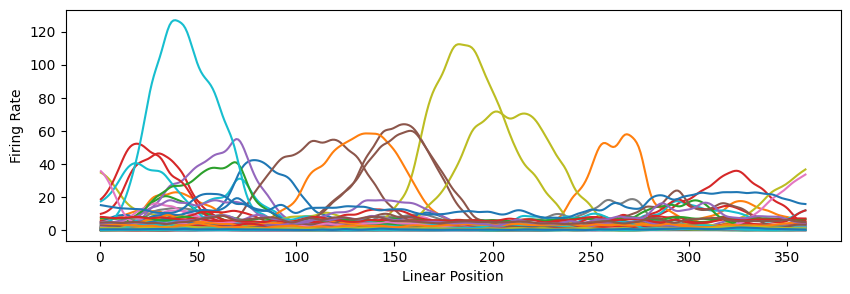

In [17]:
fig, ax = plt.subplots(figsize=(10, 3))
(classifier.place_fields_[('',0)] * 1000).plot(x="position", hue="neuron", add_legend=False, ax=ax)
ax.set_xlabel('Linear Position')
ax.set_ylabel('Firing Rate')

In [18]:
epochs = nap.IntervalSet(start=[34000], end=[36000])

spikes = hd_spikes.restrict(epochs).count(bin_size=2, time_units='ms').astype(np.bool)
spikes = spikes.astype(np.int8)

In [19]:
sleep_decoded = classifier.predict(spikes.values, time=spikes.times(), state_names=['continuous', 'fragmented', 'stationary'])

  0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:210: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  discrete_state_transition[state_k, state_k_1]


In [20]:
sleep_decoded

<xarray.Dataset> Size: 26GB
Dimensions:            (time: 1000000, state: 3, position: 360)
Coordinates:
  * time               (time) float64 8MB 3.4e+04 3.4e+04 ... 3.6e+04 3.6e+04
  * state              (state) <U10 120B 'continuous' 'fragmented' 'stationary'
  * position           (position) float64 3kB 0.4998 1.499 2.499 ... 358.3 359.3
Data variables:
    likelihood         (time, state, position) float64 9GB 0.9282 ... 0.9536
    causal_posterior   (time, state, position) float64 9GB 0.0009698 ... 9.06...
    acausal_posterior  (time, state, position) float64 9GB 0.0004574 ... 9.06...
Attributes:
    data_log_likelihood:  -254637.06465716005

In [21]:
# Highest probability for each state
max_prob_state = sleep_decoded.acausal_posterior.max(dim="position")
# Most probable position for each state
max_pos_state = sleep_decoded.acausal_posterior.idxmax(dim="position")

print("Max Probabilities:")
print(max_prob_state)
print("\nMost Probable Positions:")
print(max_pos_state)

Max Probabilities:
<xarray.DataArray 'acausal_posterior' (time: 1000000, state: 3)> Size: 24MB
array([[0.00321134, 0.00029023, 0.0553559 ],
       [0.00324538, 0.00026949, 0.05639127],
       [0.00324739, 0.00025054, 0.05737829],
       ...,
       [0.0031962 , 0.00022347, 0.06683474],
       [0.0031508 , 0.00024296, 0.06569812],
       [0.00307851, 0.00026434, 0.0645011 ]], shape=(1000000, 3))
Coordinates:
  * time     (time) float64 8MB 3.4e+04 3.4e+04 3.4e+04 ... 3.6e+04 3.6e+04
  * state    (state) <U10 120B 'continuous' 'fragmented' 'stationary'

Most Probable Positions:
<xarray.DataArray 'position' (time: 1000000, state: 3)> Size: 24MB
array([[244.38829687, 243.38875374, 244.38829687],
       [244.38829687, 243.38875374, 244.38829687],
       [244.38829687, 243.38875374, 244.38829687],
       ...,
       [239.39058119, 243.38875374, 241.38966746],
       [239.39058119, 243.38875374, 241.38966746],
       [239.39058119, 243.38875374, 241.38966746]], shape=(1000000, 3))
Coordinates

In [22]:
prob_state = sleep_decoded.acausal_posterior.sum(dim="position").to_numpy() # Shape (N, 3)
pos_max = sleep_decoded.acausal_posterior.sum(dim="state").idxmax(dim="position").to_numpy() # Shape (N,)

# Use column_stack to combine them along the second dimension
combined = np.column_stack([prob_state, pos_max])
print(combined.shape)
combined

(1000000, 4)


array([[2.52735728e-01, 9.25913122e-02, 6.54672960e-01, 2.44388297e+02],
       [2.50081065e-01, 8.59765816e-02, 6.63942354e-01, 2.44388297e+02],
       [2.47278300e-01, 7.99283437e-02, 6.72793356e-01, 2.44388297e+02],
       ...,
       [2.19594707e-01, 7.12942470e-02, 7.09111046e-01, 2.41389667e+02],
       [2.23050941e-01, 7.75115362e-02, 6.99437523e-01, 2.41389667e+02],
       [2.26414017e-01, 8.43313298e-02, 6.89254653e-01, 2.41389667e+02]],
      shape=(1000000, 4))

In [23]:
sleep_decoded_tsdf = nap.TsdFrame(t=sleep_decoded['time'].to_numpy()-30000,
                                  d=combined,
                                  columns=['continuous', 'fragmented', 'stationary', 'position'])
sleep_decoded_tsdf

Time (s)      continuous    fragmented    stationary    position
----------  ------------  ------------  ------------  ----------
4000.001        0.252736     0.0925913      0.654673     244.388
4000.003        0.250081     0.0859766      0.663942     244.388
4000.005        0.247278     0.0799283      0.672793     244.388
4000.007        0.244383     0.0744053      0.681212     244.388
4000.009        0.241437     0.0693672      0.689196     244.388
4000.011        0.23847      0.0647754      0.696755     244.388
4000.013        0.235508     0.0605933      0.703899     244.388
...
5999.987        0.20566      0.0515352      0.742805     241.39
5999.989        0.209098     0.0557945      0.735108     241.39
5999.991        0.212584     0.0604801      0.726936     241.39
5999.993        0.216093     0.0656323      0.718275     241.39
5999.995        0.219595     0.0712942      0.709111     241.39
5999.997        0.223051     0.0775115      0.699438     241.39
5999.999        0.226414   

In [24]:
sleep_decoded_tsdf.save(INTERIM_DATA_PATH / unit_id / "sleep_decoded_tdf.npz")

In [46]:
np.save(INTERIM_DATA_PATH / unit_id / "sleep_classified_angle_34000_36000.nc", sleep_decoded.acausal_posterior.to_numpy())